# RadCom Waveform Design — Benchmark Analysis

Reproduces the key figures from:
> Fan Liu et al., *"Towards Dual-functional Radar-Communication Systems: Optimal Waveform Design"*,  
> IEEE Trans. Signal Processing, 2018 (arXiv: 1711.05220)

**Figures generated:**
1. **Fig. 7** — BnB convergence behavior (2×2 grid: ARS/BRS × CVXPY/GP)
2. **Fig. 8** — Sum-rate vs similarity tolerance ε
3. **Fig. 9** — Pulse compression range profiles at different ε values

All plots are saved to `figures/` in both PNG (300 dpi) and EPS formats.

In [12]:
import sys, os
# Ensure the package root is importable
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# Project imports
from src.utils.config import SystemConfig, BnBConfig
from src.signal_proc import generate_chirp, generate_channel, generate_symbols
from src.signal_proc.pulse_compression import pulse_compress
from src.optimizer import bnb_solve, optimize_waveform, WaveformMatrixOptimizer
from src.optimizer.solvers.lb_gp import LBSolverGP
from src.metrics import sum_rate, ConvergenceMetric

# Output directory
OUTPUT_DIR = os.path.join('..', 'figures')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('All imports OK')

All imports OK


---
## 1. Figure 7 — BnB Convergence Behavior

Single-column optimization with N=16 antennas, K=4 users, ε=1.0.  
Compares all 4 solver combinations:

| Panel | Rule | LB Solver | UB Solver |
|-------|------|-----------|-----------|
| (a)   | ARS  | CVXPY/SCS | SLSQP     |
| (b)   | BRS  | CVXPY/SCS | SLSQP     |
| (c)   | ARS  | GP (FISTA)| GP + PR₁  |
| (d)   | BRS  | GP (FISTA)| GP + PR₁  |

In [13]:
# ===== Fig. 7 — Convergence =====
N, K, eps, PT = 16, 4, 1.0, 1.0
max_iter, tol, seed = 200, 1e-4, 42

print('=' * 64)
print(f'  FIGURE 7: BnB Convergence  (N={N}, K={K}, eps={eps})')
print('=' * 64)

np.random.seed(seed)
H = generate_channel(K, N)
Ht = np.sqrt(PT / N) * H
s = generate_symbols(K, 1).ravel()
x0 = np.exp(1j * np.pi * np.arange(N) ** 2 / N)  # single chirp column

# Run all 4 solver combinations
combos = [
    ('ARS', 'cvxpy', 'slsqp', 'ARS + CVXPY/SLSQP'),
    ('BRS', 'cvxpy', 'slsqp', 'BRS + CVXPY/SLSQP'),
    ('ARS', 'gp',    'gp',    'ARS + GP'),
    ('BRS', 'gp',    'gp',    'BRS + GP'),
]

results_fig7 = {}
for rule, lb_sol, ub_sol, label in combos:
    print(f'\n  {label} ...')
    t0 = time.time()
    _, obj, lb_h, ub_h = bnb_solve(
        Ht, s, x0, eps,
        rule=rule, lb_solver=lb_sol, ub_solver=ub_sol,
        tol=tol, max_iter=max_iter, verbose=True,
    )
    dt = time.time() - t0
    results_fig7[label] = (lb_h, ub_h)
    gap = ub_h[-1] - lb_h[-1] if ub_h else float('inf')
    print(f'  {len(ub_h)} iters, {dt:.1f}s, obj={obj:.6f}, gap={gap:.6f}')

  FIGURE 7: BnB Convergence  (N=16, K=4, eps=1.0)

  ARS + CVXPY/SLSQP ...


KeyboardInterrupt: 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


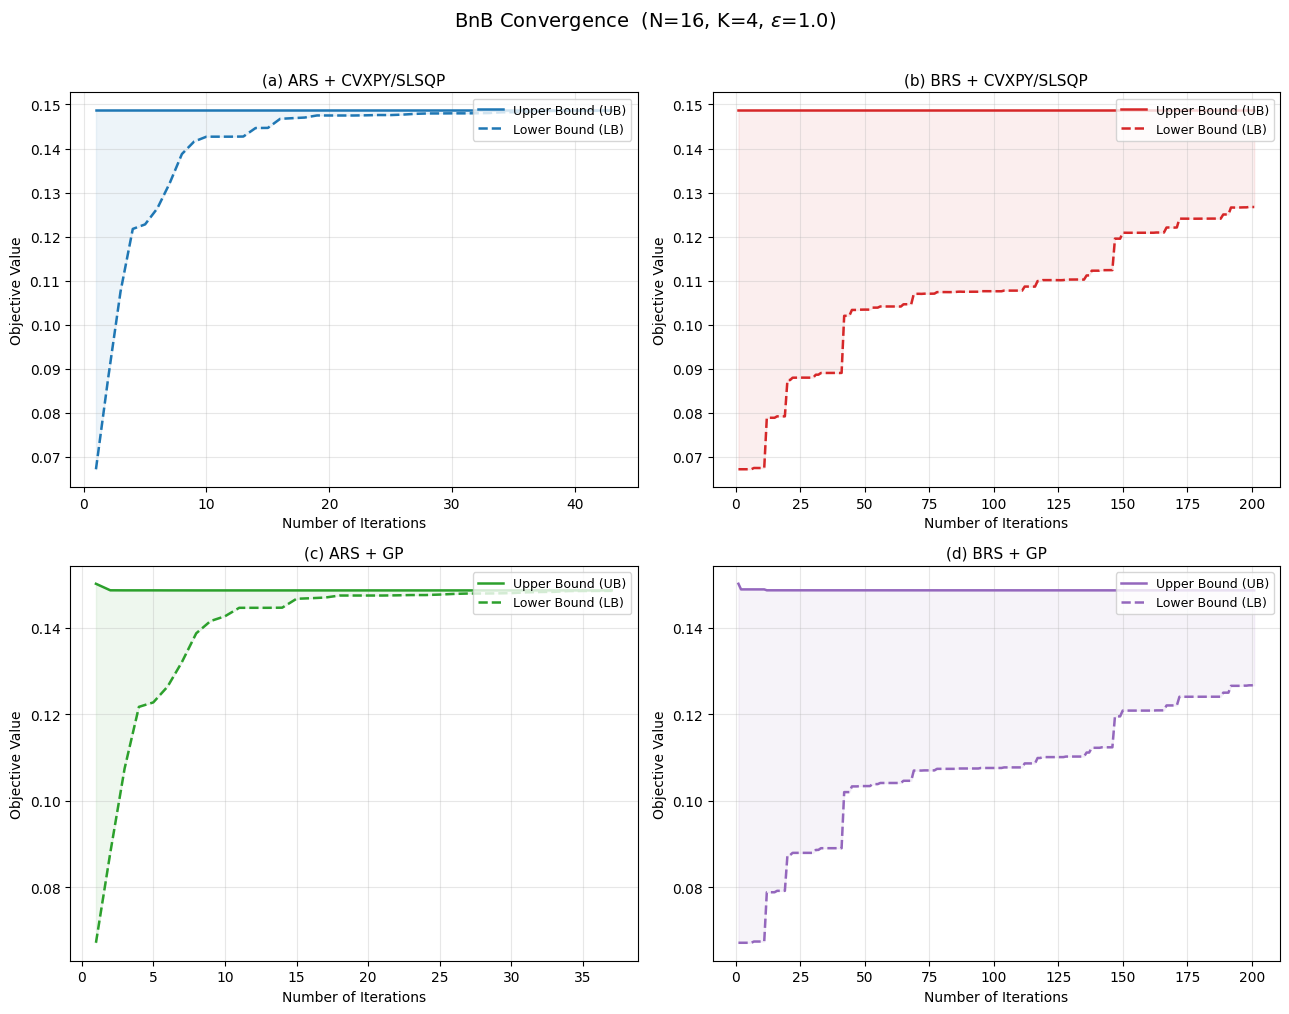

Saved: ..\figures\fig7_convergence.png


In [ ]:
# ===== Fig. 7 — Plot (2x2 grid) =====
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
layout = [
    (0, 0, 'ARS + CVXPY/SLSQP', 'tab:blue',   'a'),
    (0, 1, 'BRS + CVXPY/SLSQP', 'tab:red',     'b'),
    (1, 0, 'ARS + GP',           'tab:green',   'c'),
    (1, 1, 'BRS + GP',           'tab:purple',  'd'),
]

for row, col, label, clr, letter in layout:
    ax = axes[row, col]
    lb_arr, ub_arr = results_fig7[label]
    iters = np.arange(1, len(ub_arr) + 1)

    ax.plot(iters, ub_arr, '-',  color=clr, lw=1.8, label='Upper Bound (UB)')
    ax.plot(iters, lb_arr, '--', color=clr, lw=1.8, label='Lower Bound (LB)')
    ax.fill_between(iters, lb_arr, ub_arr, color=clr, alpha=0.08)

    all_vals = np.concatenate([lb_arr, ub_arr])
    ylo = max(0, all_vals.min() - 0.05 * (all_vals.max() - all_vals.min()))
    yhi = all_vals.max() + 0.05 * (all_vals.max() - all_vals.min())
    ax.set_ylim(ylo, yhi)

    ax.set_title(f'({letter}) {label}', fontsize=11)
    ax.set_xlabel('Number of Iterations', fontsize=10)
    ax.set_ylabel('Objective Value', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f'BnB Convergence  (N={N}, K={K}, $\\varepsilon$={eps})',
    fontsize=14, y=1.01,
)
plt.tight_layout()

path_png = os.path.join(OUTPUT_DIR, 'fig7_convergence.png')
path_eps = os.path.join(OUTPUT_DIR, 'fig7_convergence.eps')
plt.savefig(path_png, dpi=300, bbox_inches='tight')
plt.savefig(path_eps, bbox_inches='tight')
plt.show()
print(f'Saved: {path_png}')

### Convergence Metrics

In [ ]:
# ===== Convergence metrics for each solver combo =====
cm = ConvergenceMetric()
print(f'{"Method":<25} {"Iters":>6} {"Final Gap":>12} {"Iters to 1e-3":>15}')
print('-' * 62)
for label in ['ARS + CVXPY/SLSQP', 'BRS + CVXPY/SLSQP', 'ARS + GP', 'BRS + GP']:
    lb_arr, ub_arr = results_fig7[label]
    res = cm.compute(lb_history=lb_arr, ub_history=ub_arr, tol=1e-3)
    print(f'{label:<25} {res.metadata["n_iterations"]:>6} {res.values["final_gap"]:>12.6f} {res.values["iters_to_tol"]:>15}')

Method                     Iters    Final Gap   Iters to 1e-3
--------------------------------------------------------------
ARS + CVXPY/SLSQP             43     0.000067              26
BRS + CVXPY/SLSQP            201     0.021976             201
ARS + GP                      37     0.000095              25
BRS + GP                     201     0.021973             201


---
## 2. Figure 8 — Sum-Rate vs Similarity Tolerance ε

N=16, K=4, SNR=10 dB, L=20 frame length.  
Averaged over `n_trials` independent channel realizations.

Three curves:
- **BnB (Global Optimum)** — full branch-and-bound with GP solvers
- **Convex Relaxation Bound** — QP-LB solution (not CM-feasible)
- **AWGN Capacity** — MUI=0 upper bound

In [ ]:
# ===== Fig. 8 — Sum-Rate vs Epsilon =====
N, K, L, PT, SNR_dB = 16, 4, 30, 1.0, 10.0
n_trials = 5
seed = 0

print('=' * 64)
print(f'  FIGURE 8: Sum-Rate vs eps  (N={N}, K={K}, SNR={SNR_dB}dB, L={L}, trials={n_trials})')
print('=' * 64)

N0 = PT / 10.0 ** (SNR_dB / 10.0)
epsilons = np.array([0.05, 0.2, 0.4, 0.6, 0.8, 1.0, 1.3, 1.6, 2.0])
sc = np.sqrt(PT / N)
awgn_cap = K * np.log2(1.0 + 1.0 / N0)

r_bnb = np.zeros(len(epsilons))
r_relax = np.zeros(len(epsilons))

t0_total = time.time()

for trial in range(n_trials):
    np.random.seed(seed + trial)
    H = generate_channel(K, N)
    S = generate_symbols(K, L)
    X0 = generate_chirp(N, L, PT)
    Ht = sc * H
    X0n = X0 / sc

    # Precompute GP step size
    eigs = np.linalg.eigvalsh(Ht.conj().T @ Ht)
    step = 1.0 / max(2.0 * eigs.max(), 1e-12)

    print(f'\n  Trial {trial + 1}/{n_trials}')

    for ei, eps_val in enumerate(epsilons):
        hw0 = np.arccos(np.clip(1 - eps_val**2 / 2, -1, 1))
        X_bnb_mat = np.zeros((N, L), dtype=complex)
        X_rel_mat = np.zeros((N, L), dtype=complex)

        for t in range(L):
            x0c = X0n[:, t]
            sc_col = S[:, t]
            lb = np.angle(x0c) - hw0
            ub = np.angle(x0c) + hw0

            # BnB (GP solver for speed)
            xb, _, _, _ = bnb_solve(
                Ht, sc_col, x0c, eps_val,
                rule='ARS', lb_solver='gp', ub_solver='gp',
                tol=5e-3, max_iter=40, gp_iters=50,
            )
            X_bnb_mat[:, t] = (xb if xb is not None else x0c) * sc

            # Convex relaxation (GP-LB only, step computed internally)
            relax_solver = LBSolverGP(max_iter=100, step=step)
            _, xl = relax_solver.solve(Ht, sc_col, lb, ub)
            X_rel_mat[:, t] = (xl if xl is not None else x0c) * sc

        r_bnb[ei] += sum_rate(H, X_bnb_mat, S, N0)
        r_relax[ei] += sum_rate(H, X_rel_mat, S, N0)

        print(f'    eps={eps_val:.2f}  BnB={r_bnb[ei]/(trial+1):.2f}  Relax={r_relax[ei]/(trial+1):.2f} bps/Hz')

r_bnb /= n_trials
r_relax /= n_trials
dt_total = time.time() - t0_total
print(f'\n  Total time: {dt_total:.0f}s')

  FIGURE 8: Sum-Rate vs eps  (N=16, K=4, SNR=10.0dB, L=30, trials=5)

  Trial 1/5
    eps=0.05  BnB=2.17  Relax=2.17 bps/Hz
    eps=0.20  BnB=2.62  Relax=2.62 bps/Hz
    eps=0.40  BnB=3.48  Relax=3.49 bps/Hz
    eps=0.60  BnB=4.75  Relax=4.80 bps/Hz
    eps=0.80  BnB=6.60  Relax=6.78 bps/Hz
    eps=1.00  BnB=9.20  Relax=9.58 bps/Hz
    eps=1.30  BnB=12.75  Relax=13.05 bps/Hz
    eps=1.60  BnB=13.79  Relax=13.83 bps/Hz
    eps=2.00  BnB=13.83  Relax=13.84 bps/Hz

  Trial 2/5
    eps=0.05  BnB=2.47  Relax=2.47 bps/Hz
    eps=0.20  BnB=2.97  Relax=2.97 bps/Hz
    eps=0.40  BnB=3.89  Relax=3.90 bps/Hz
    eps=0.60  BnB=5.20  Relax=5.25 bps/Hz
    eps=0.80  BnB=6.98  Relax=7.13 bps/Hz
    eps=1.00  BnB=9.25  Relax=9.56 bps/Hz
    eps=1.30  BnB=12.36  Relax=12.70 bps/Hz
    eps=1.60  BnB=13.65  Relax=13.70 bps/Hz
    eps=2.00  BnB=13.78  Relax=13.80 bps/Hz

  Trial 3/5
    eps=0.05  BnB=2.41  Relax=2.41 bps/Hz
    eps=0.20  BnB=2.92  Relax=2.92 bps/Hz
    eps=0.40  BnB=3.86  Relax=3.87 bps/H

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


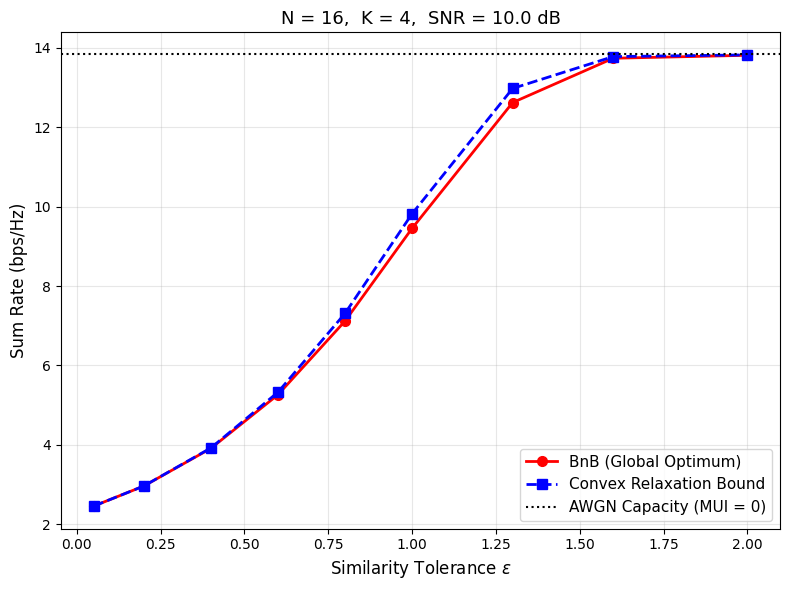

Saved: ..\figures\fig8_rate_vs_epsilon.png
AWGN capacity = 13.84 bps/Hz


In [ ]:
# ===== Fig. 8 — Plot =====
plt.figure(figsize=(8, 6))
plt.plot(epsilons, r_bnb, 'r-o', lw=2, ms=7, label='BnB (Global Optimum)')
plt.plot(epsilons, r_relax, 'b--s', lw=2, ms=7, label='Convex Relaxation Bound')
plt.axhline(awgn_cap, color='k', ls=':', lw=1.5, label='AWGN Capacity (MUI = 0)')

plt.xlabel(r'Similarity Tolerance $\varepsilon$', fontsize=12)
plt.ylabel('Sum Rate (bps/Hz)', fontsize=12)
plt.title(f'N = {N},  K = {K},  SNR = {SNR_dB} dB', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

path_png = os.path.join(OUTPUT_DIR, 'fig8_rate_vs_epsilon.png')
path_eps = os.path.join(OUTPUT_DIR, 'fig8_rate_vs_epsilon.eps')
plt.savefig(path_png, dpi=300)
plt.savefig(path_eps)
plt.show()
print(f'Saved: {path_png}')
print(f'AWGN capacity = {awgn_cap:.2f} bps/Hz')

---
## 3. Figure 9 — Pulse Compression Range Profiles

Compares the pulse compression profile of the **reference LFM chirp** (eq. 33)
against the **BnB-optimized waveform** at three similarity tolerances
ε ∈ {0.05, 0.4, 1.0}.

As ε increases, the optimizer has more freedom to reshape the waveform for
communication, which degrades the radar sidelobe structure.

  FIGURE 9: Pulse Compression — Reference vs Optimized
  epsilon = 0.05 ...
    col 1/30 done  (obj=5.426309, iters=0)
    col 2/30 done  (obj=7.139407, iters=50)
    col 3/30 done  (obj=6.069496, iters=1)
    col 4/30 done  (obj=4.128399, iters=0)
    col 5/30 done  (obj=8.011790, iters=50)
    col 6/30 done  (obj=13.839276, iters=50)
    col 7/30 done  (obj=8.763213, iters=0)
    col 8/30 done  (obj=6.953239, iters=0)


KeyboardInterrupt: 

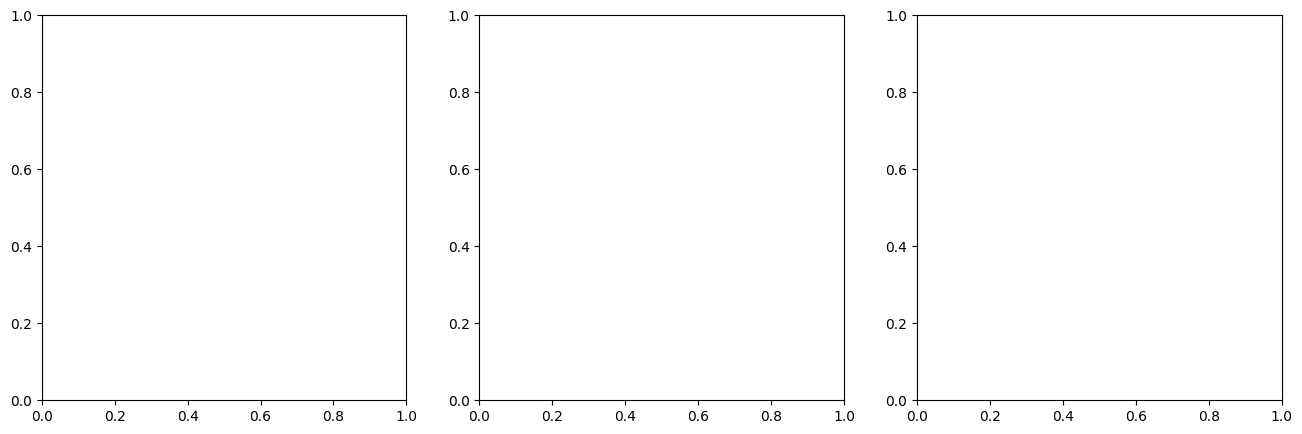

In [14]:
# ===== Fig. 9 — Pulse Compression: Reference vs BnB-Optimized =====
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftshift
from scipy.signal.windows import taylor

from src.signal_proc import generate_chirp, generate_channel, generate_symbols
from src.optimizer import optimize_waveform

OUTPUT_DIR = os.path.join('..', 'figures')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('=' * 64)
print('  FIGURE 9: Pulse Compression — Reference vs Optimized')
print('=' * 64)

NT_pc = 16   # Number of transmit antennas
N_pc = 30    # Number of samples (frame length)
K_pc = 4     # Number of users
Nf = 160     # IFFT points for range profile
PT_pc = 1.0
epsilons_pc = [0.05, 0.4, 1.0]

# --- Reference chirp (unitary norm, matches eq. 33 exactly) ---
S0_ref = generate_chirp(NT_pc, N_pc, PT_pc, norm='power')

# --- Chirp for optimizer (power norm, |X0_{n,l}| = sqrt(PT/N)) ---
X0_opt = generate_chirp(NT_pc, N_pc, PT_pc, norm='power')

# Pulse compression helper (inline to keep self-contained)
def _pulse_compress(waveform, n_fft, sll=40):
    """3-step pulse compression with Taylor window."""
    wf = np.asarray(waveform).ravel()
    Nw = len(wf)
    f = fft(wf)
    tw = taylor(Nw, nbar=4, sll=sll, norm=False)
    fp = f * np.conj(f) * tw
    rp = ifft(fp, n_fft)
    rp_shifted = fftshift(rp)
    rp_mag = 20 * np.log10(np.abs(rp_shifted))
    rp_mag -= np.max(rp_mag)
    bins = np.arange(-n_fft / 2, n_fft / 2)
    return bins, rp_mag

# --- Reference chirp pulse compression (first row) ---
ref_wf = S0_ref[0, :]
ref_bins, ref_dB = _pulse_compress(ref_wf, Nf)

# --- Generate data for BnB optimization ---
# np.random.seed(42)
H_pc = generate_channel(K_pc, NT_pc)
S_pc = generate_symbols(K_pc, N_pc)

# --- Plot: 1x3 subplots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, eps_val in enumerate(epsilons_pc):
    print(f'  epsilon = {eps_val} ...')

    # BnB-optimized waveform (power-normed X0 fed to optimizer)
    X_opt = optimize_waveform(
        H_pc, S_pc, X0_opt, eps_val, PT=PT_pc, verbose_col=True,
        rule='ARS', lb_solver='cvxpy', ub_solver='slsqp',
        tol=1e-4, max_iter=50
    )

    # Pulse compression of first transmit element
    opt_wf = X_opt[0, :]
    opt_bins, opt_dB = _pulse_compress(opt_wf, Nf)

    ax = axes[i]
    ax.plot(ref_bins, ref_dB, color='teal', lw=1.0, label='Reference Chirp')
    ax.plot(opt_bins, opt_dB, color='red', lw=1.0, alpha=0.85, label='BnB Optimized')
    ax.set_ylim([-90, 0])
    ax.set_xlim([-80, 80])
    ax.set_xlabel('IFFT bin index', fontsize=10)
    ax.set_ylabel('Magnitude (dB)', fontsize=10)
    ax.set_title(f'$\\varepsilon = {eps_val}$', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=9, loc='upper right')

fig.suptitle('Pulse Compression — Reference Chirp vs BnB Optimized', fontsize=14, y=1.02)
plt.tight_layout()

path_png = os.path.join(OUTPUT_DIR, 'fig9_pulse_compression.png')
path_eps_f = os.path.join(OUTPUT_DIR, 'fig9_pulse_compression.eps')
plt.savefig(path_png, dpi=300, bbox_inches='tight')
plt.savefig(path_eps_f, bbox_inches='tight')
plt.show()
print(f'Saved: {path_png}')

---
## 4. Dataset Generation Demo

Demonstrates the `DatasetGenerator` for creating HDF5 datasets of
optimization input–output pairs suitable for ML training.

In [ ]:
from src.data import DatasetGenerator

# Use fast GP solvers and a small system for demo purposes
sys_cfg = SystemConfig(N=8, K=2, L=4, PT=1.0, SNR_dB=10.0)
bnb_cfg = BnBConfig(
    rule='ARS', lb_solver='gp', ub_solver='gp',
    tol=1e-2, max_iter=30, gp_max_iter=50,
)

gen = DatasetGenerator(
    output_dir=os.path.join(OUTPUT_DIR, '..', 'datasets'),
    sys_config=sys_cfg, bnb_config=bnb_cfg,
)

# Generate and save 3 samples
path = gen.generate_and_save(3, epsilon=1.0, seed=42, filename='demo_dataset.h5')
print(f'\nDataset saved: {path}')

# Load and verify
samples, meta = DatasetGenerator.load_hdf5(path)
print(f'Loaded {len(samples)} samples')
print(f'Metadata: {meta}')
for i, s in enumerate(samples):
    print(f'  Sample {i}: rate={s.sum_rate:.4f} bps/Hz, CM dev={np.max(np.abs(np.abs(s.X_opt) - np.sqrt(sys_cfg.PT/sys_cfg.N))):.2e}')

---
## 5. Summary Table

Collects all key metrics from the experiments above.

In [ ]:
print('\n' + '=' * 70)
print('  EXPERIMENT SUMMARY')
print('=' * 70)

print('\n  Fig. 7 — Convergence:')
for label in ['ARS + CVXPY/SLSQP', 'BRS + CVXPY/SLSQP', 'ARS + GP', 'BRS + GP']:
    lb_arr, ub_arr = results_fig7[label]
    gap = ub_arr[-1] - lb_arr[-1]
    print(f'    {label:<25}  iters={len(ub_arr):>4}  gap={gap:.6f}')

print(f'\n  Fig. 8 — Rate vs Epsilon (N={N}, K={K}, SNR={SNR_dB}dB):')
print(f'    AWGN Capacity = {awgn_cap:.2f} bps/Hz')
for i, eps_val in enumerate(epsilons):
    print(f'    eps={eps_val:.2f}  BnB={r_bnb[i]:.2f}  Relax={r_relax[i]:.2f} bps/Hz')

print(f'\n  All figures saved to: {os.path.abspath(OUTPUT_DIR)}')
print('=' * 70)